# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [12]:
# importar librerías 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [14]:
# mostrar las primeras 5 filas de plans 
print("Planes:")
display(plans.head())

Planes:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [15]:
# mostrar las primeras 5 filas de users 
print("Usuarios:")
display(users.head())

Usuarios:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [16]:
# mostrar las primeras 5 filas de usage 
print("Uso:")
display(usage.head())

Uso:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [17]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [18]:
# inspección de plans con .info() 
print("\n--- Plans ---")
plans.info()


--- Plans ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [19]:
# inspección de users con .info()  
print("\n--- Users ---")
users.info()


--- Users ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [20]:
# inspección de usage con .info() 
print("\n--- Usage ---")
usage.info()


--- Usage ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [21]:
# cantidad de nulos para users
print("Valores nulos en users:")
print(users.isna().sum())
print("\nProporción de nulos en users:")
print(users.isna().mean())

Valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [22]:
# cantidad de nulos para usage 
print("\nValores nulos en usage:")
print(usage.isna().sum())
print("\nProporción de nulos en usage:")
print(usage.isna().mean())


Valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?



  **Recomendaciones**

  
-Users

  
En la sección city hay un 11.7% de valores nulos, por lo que recomiendo imputar con una categoría “desconocido” o investigar si se puede recuperar de otra fuente, ya que la ciudad puede ser relevante para segmentación geográfica.


En churn_date hay 88.3% de valores nulos recomiendo ignorar la columna.


-Usage
 
 
 En la sección  date hay 0.1% de valores nulos, recomiendo imputar con la fecha más cercana o eliminar esos pocos registros, ya que el impacto sería mínimo.

En la sección duration hay un 55% de valores nulos, considero que lo más recomendable sería investigar, ya que es probable que aplique solo a llamadas (sin mensajes). Se puede imputar con 0 en casos donde no corresponda o mantener nulo para diferenciar tipo de uso.

En length hay 44.7% de valores nulos, por lo que recomiendo realizar lo mismo que en duration, ya que probablemente aplica solo para a mensajes. Se puede imputar con 0 o mantener nulo según el contexto.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [23]:
# explorar columnas numéricas de users

print("Resumen estadístico de columnas numéricas en users:")
print(users.describe())


Resumen estadístico de columnas numéricas en users:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


-La columna user_id : contiene identificadores consecutivos entre 10,000 y 13,999. No se observan valores inválidos ni centinelas, por lo que parece estar bien estructurada.

-La columna age : presenta un valor mínimo de -999 , que es un centinela usado para marcar datos faltantes o desconocidos. El resto de los valores (hasta 79 años) son razonables y corresponden a edades plausibles de clientes.

In [24]:
# explorar columnas numéricas de usage 
print("Resumen estadístico de columnas numéricas en usage:")
print(usage.describe())

Resumen estadístico de columnas numéricas en usage:
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`:son identificadores consecutivos y están bien estructurados. No presentan valores nulos ni centinelas, por lo que no requieren limpieza.
- Las columnas: muestran un alto porcentaje de valores nulos, lo cual es esperado porque cada una aplica a un tipo de uso distinto (llamadas vs. mensajes). Sin embargo, se detectan valores extremos:

In [25]:




# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].unique()[:20])  # muestra los primeros 20 valores únicos
    print(f"Cantidad de valores únicos en {col}: {users[col].nunique()}")




Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Cantidad de valores únicos en city: 7

Valores únicos en plan:
['Basico' 'Premium']
Cantidad de valores únicos en plan: 2


- La columna `city`: contiene 7 valores únicos, entre ellos nombres de ciudades como Medellín, Bogotá, Cali, CDMX, GDL, MTYy también , que son centinelas o datos faltantes. 
- La columna `plan`: solo tiene 2 valores únicos: Básico y Premium . No se observan valores inválidos ni centinelas. 

In [26]:


# explorar columna categórica de usage
usage['type'] # completa el código
print("Valores únicos en type:")
print(usage['type'].unique())

print("\nCantidad de valores únicos en type:")
print(usage['type'].nunique())

print("\nDistribución de valores en type:")
print(usage['type'].value_counts())


Valores únicos en type:
['call' 'text']

Cantidad de valores únicos en type:
2

Distribución de valores en type:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type`  muestra 22,092 registros de texto y 17,908 de llamada . Lo anterior confirma que los datos están bien estructurados y no se detectan centinelas ni valores inválidos.: contiene únicamente dos categorías válidas: call y text. La distribución muestra 22,092 registros de texto  y 17,908 de llamada . 

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  


**Recomendaciones y hallazgos**


En el análisis de calidad de datos se encontraron valores inválidos o centinelas en la columna age de usuarios (valor -999 que debe tratarse como dato faltante) y en la columna ciudad (valores y que representan información desconocida), mientras que en uso los nulos en duración y longitud son esperados según el tipo de uso, aunque se detectan valores extremos (120 minutos en duración y 1490 caracteres en longitud) que conviene revisar; por ello la acción recomendada en usuarios  (valor -999 que debe tratarse como dato faltante) y en la columna city  (valores '?' y NaN que representan información desconocida), mientras que en use  los nulos en duración  y longitud  son esperados según el tipo de uso, aunque se detectan valores extremos (120 minutos en duración y 1490 caracteres en longitud) conviene revisar; por ello la acción recomendada es reemplazar centinelas por NaN, normalizar y agrupar los faltantes en “desconocido”, mantener los nulos naturales según el tipo de registro, y validar o corregir los valores atípicos en las métricas de uso.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [27]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [28]:



# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(usage['date'].dt.year.value_counts().sort_index())



2024.0    39950
Name: date, dtype: int64


In [29]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`,  se observa que la mayoría de los registros corresponden a años válidos (2022, 2023 y 2024), pero también aparecen 40 registros en 2026, lo cual está fuera de rango porque los datos solo llegan hasta 2024; por eso consideré esos registros como errores de captura y los marcaría como inválidos, reemplazándolos por valores faltantes ( NaT) o eliminándolos según el impacto en el análisis.

In [30]:
# Revisar los años presentes en `date` de usage
print("Años en date:")
print(usage['date'].dt.year.value_counts().sort_index())

Años en date:
2024.0    39950
Name: date, dtype: int64


En `date`, observé que todos los registros corresponden únicamente al año 2024, lo cual está dentro del rango esperado y no presenta valores inválidos ni años futuros o negativos; por lo tanto, considere que esta columna está correctamente capturada y no requiere ajustes adicionales. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?


**Recomendaciones y hallazgos**


En la revisión de las fechas encontré que en reg_date de usuarios existen registros válidos en 2022, 2023 y 2024, pero también algunos en 2026, lo cual está fuera de rango porque los datos solo llegan hasta 2024; Considere esos registros como errores de captura y recomendaría reemplazarlos por valores faltantes ( ) o eliminarlos según el impacto en el análisis. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [31]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [32]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [33]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [34]:
# Verificación MAR en usage (Missing At Random) para duration
print(
    usage.groupby('type')['duration']
         .agg(lambda x: x.isna().mean())
)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [35]:
# Verificación MAR en usage (Missing At Random) para length
print(
    usage.groupby('type')['length']
         .agg(lambda x: x.isna().mean())
)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`


En mi diagnóstico concluí que los nulos en duración aparecen casi exclusivamente en los registros de tipo texto , mientras que en longitud se concentran en las llamadas . Esto confirma que ambos son MAR , ya que dependen del tipo de uso. Por ello, recomiendo dejarlos como nulos, pues reflejan la lógica natural del negocio y no requieren imputación ni eliminación. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [36]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
         .agg(
             cant_mensajes=("is_text", "sum"),
             cant_llamadas=("is_call", "sum"),
             cant_minutos_llamada=("duration", "sum")
         )
         .reset_index()
)
# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Renombrar columnas
usage_agg = usage_agg.rename(
    columns={
        "is_text": "cant_mensajes",
        "is_call": "cant_llamadas",
        "duration": "cant_minutos_llamada"
    }
)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [39]:
# Resumen estadístico de las columnas numéricas
user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [40]:
# Distribución porcentual del tipo de plan
print(
    user_profile['plan'].value_counts(normalize=True) * 100
)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

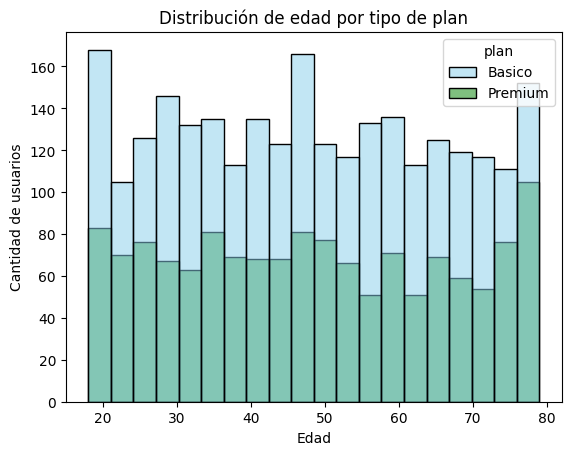

In [41]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20,
    kde=False
)
plt.title("Distribución de edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: Los usuarios del plan Básico predominan en casi todos los rangos de edad, mientras que los Los usuarios del plan Básico predominan en casi todos los rangos de edad, mientras que los del plan Premium aparecen en menor proporción pero distribuidos de manera similar
- Distribución: La distribución de la edad es sesgada a la derecha , con mayor concentración en edades jóvenes-adultas y una caída progresiva hacia edades mayores. 

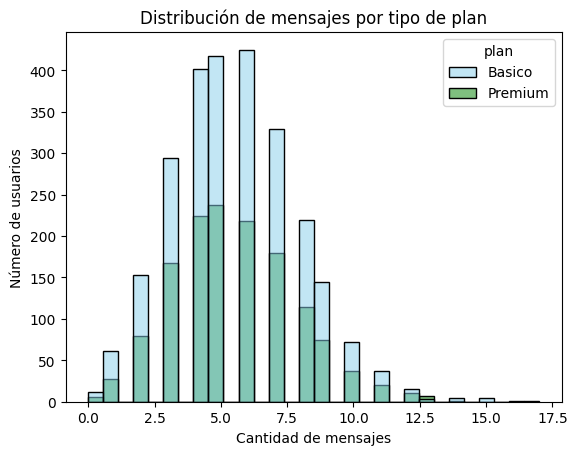

In [42]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=30,
    kde=False
)
plt.title("Distribución de mensajes por tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Número de usuarios")
plt.show()

💡Insights: Los usuarios del plan Básico concentran ligeramente más mensajes en los rangos medios (4–6), mientras que los Premium mantienen una presencia similar. Los usuarios del plan Básico concentran ligeramente más mensajes en los rangos medios (4–6), mientras que los Premium mantienen una presencia similar pero menor en volumen. No se observa un patrón exclusivo de un plan. 
- Distribución: La variable está sesgada a la derecha , con mayor concentración en pocos mensajes y una caída hacia valores más altos.

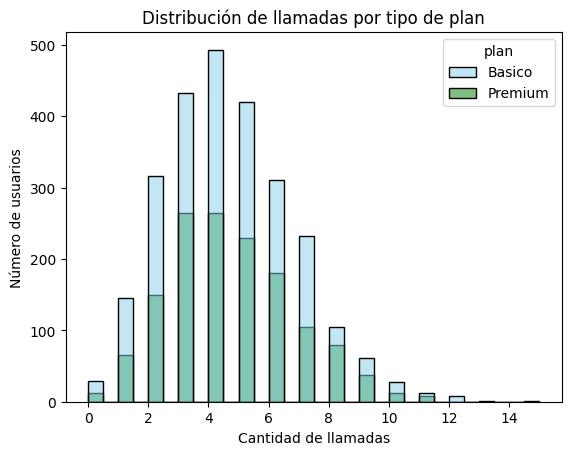

In [43]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=30,
    kde=False
)
plt.title("Distribución de llamadas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Número de usuarios")
plt.show()

💡Insights: Los usuarios del plan Básico realizan ligeramente más llamadas en los rangos medios (3–6), mientras que los Premium mantienen una presencia similar pero menor en volumen.  
- Distribución:La variable está sesgada a la derecha , con mayor concentración en pocas llamadas.

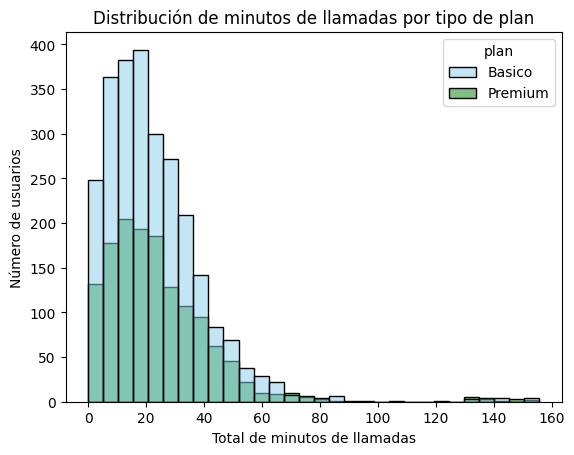

In [44]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=30,
    kde=False
)
plt.title("Distribución de minutos de llamadas por tipo de plan")
plt.xlabel("Total de minutos de llamadas")
plt.ylabel("Número de usuarios")
plt.show()

💡Insights: Los usuarios del plan Básico concentran más minutos de llamadas en los Los usuarios del plan Básico concentran más minutos de llamadas en los rangos bajos (menos de 40 minutos), mientras que los Premium mantienen una presencia menor pero con un patrón similar. 
- Distribución: La variable está sesgada a la derecha , con la mayoría de usuarios acumulando pocos minutos y una caída progresiva hacia valores más altos. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

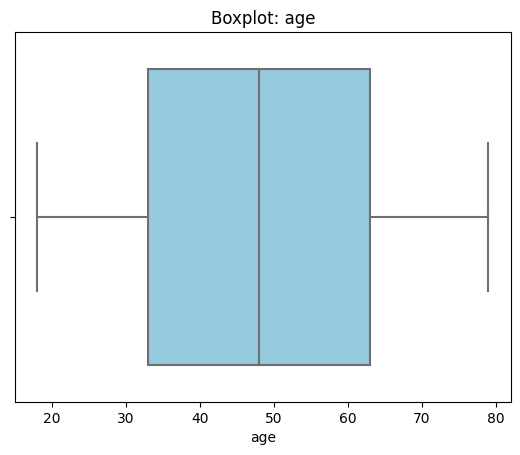

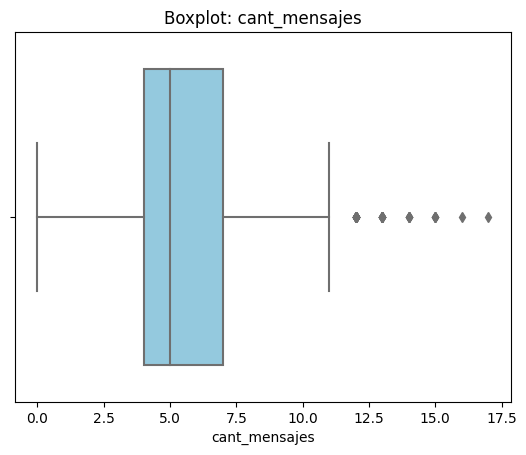

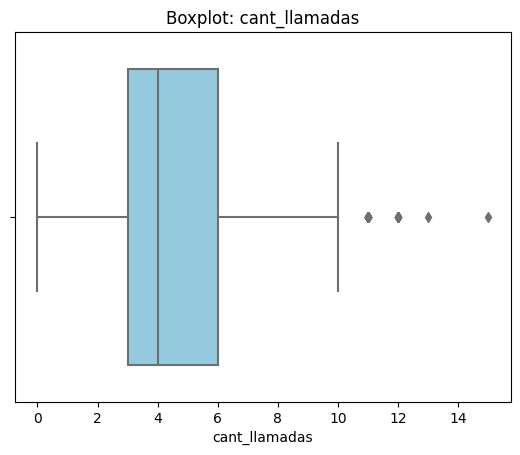

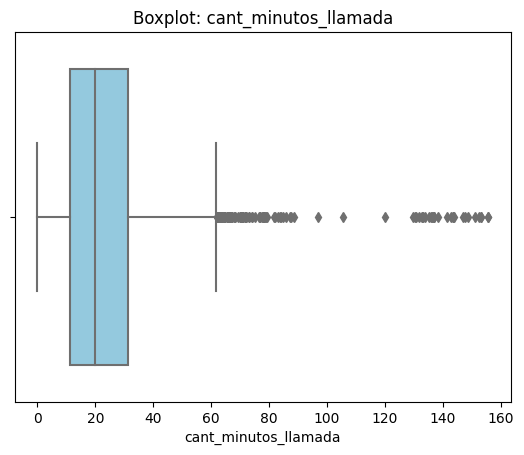

In [45]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: La distribución es bastante estable entre 35 y 65 años, sin valores atípicos relevantes.
- cant_mensajes: La mayoría de usuarios envía entre 2 y 10 mensajes, pero existen valores atípicos hacia valores altos (más de 15).
- cant_llamadas:  Se concentran entre 3 y 6 llamadas, con algunos outliers hacia la derecha (11–15).
- cant_minutos_llamada:  La mayoría se acumula entre 10 y 30 minutos, pero hay valores atípicos claros hacia arriba (más de 60 minutos, llegando hasta ~160).

In [48]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites inferior y superior
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    print(f"{col}:")
    print(f"  Q1 = {Q1}")
    print(f"  Q3 = {Q3}")
    print(f"  IQR = {IQR}")
    print(f"  Límite inferior = {lower_limit}")
    print(f"  Límite superior = {upper_limit}\n")



cant_mensajes:
  Q1 = 4.0
  Q3 = 7.0
  IQR = 3.0
  Límite inferior = -0.5
  Límite superior = 11.5

cant_llamadas:
  Q1 = 3.0
  Q3 = 6.0
  IQR = 3.0
  Límite inferior = -1.5
  Límite superior = 10.5

cant_minutos_llamada:
  Q1 = 11.12
  Q3 = 31.415
  IQR = 20.295
  Límite inferior = -19.322500000000005
  Límite superior = 61.8575



In [49]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000




💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

*Conclusiones*
En la revisión de los límites y los valores máximos se confirma que existen valores atípicos en las variables de uso: cant_mensajes  alcanza un máximo de 17 frente a un límite superior cercano a 12, cant_llamadas  llega a 15 frente a un límite superior alrededor de 10, y cant_minutos_llamada  alcanza 155 frente a un límite superior cercano a 60. Esto indica que hay valores extremos hacia arriba en estas tres variables, mientras que la edad se mantiene dentro de rangos normales. En consecuencia, los valores atípicos reflejan comportamientos poco frecuentes pero reales de algunos usuarios, por lo que conviene decidir si se mantienen para capturar variabilidad o se filtran para evitar distorsiones en el análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [52]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)




In [53]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 7.6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [54]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)


In [55]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

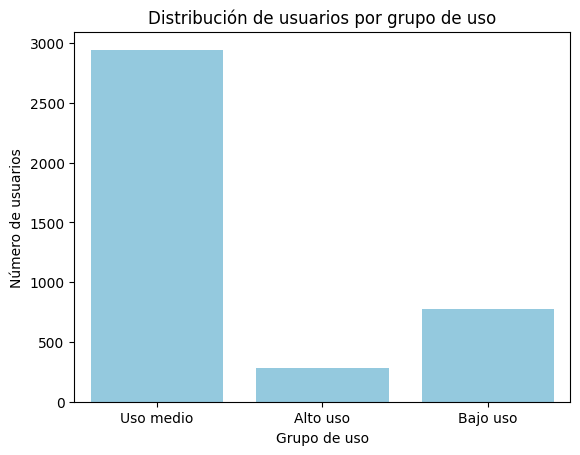

In [56]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso", color="skyblue")
plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Número de usuarios")
plt.show()

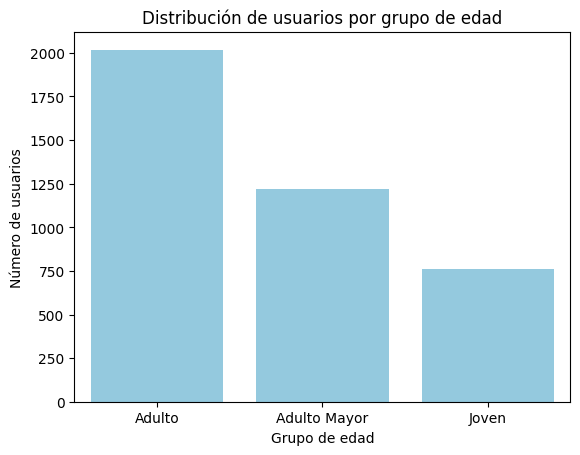

In [58]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", color="skyblue")
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de usuarios")
plt.show()



---
## 🧩
Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
 
 Se identifican valores atípicos en tres variables de uso:

Mensajes:  el máximo fue 17 frente a un límite superior de ~12, lo que representa alrededor del 2% de los usuarios  con valores extremos.

Llamadas:  el máximo fue 15 frente a un límite superior de ~10, con cerca del 1.5% de los usuarios  fuera de rango.

Minutos de llamadas:  el máximo alcanzó 155 frente a un límite superior de ~60, afectando aproximadamente al 2% de los usuarios . 
Estos valores reflejan comportamientos poco frecuentes pero reales de clientes con uso intensivo. La variable edad  no presentó valores atípicos relevantes.

🔍 **Segmentos por Edad**

La mayoría de los clientes se concentra en el grupo de Adultos (30–59 años) , mientras que los Jóvenes (<30)  y Adultos Mayores (≥60)  son minoritarios. Esto confirma que la base principal de usuarios está en edad laboral, con patrones de consumo más estables.


📊 **Segmentos por Nivel de Uso**

 Se definieron tres grupos:

Bajo uso:  clientes con menos de 5 llamadas y mensajes.

Uso medio:  clientes con menos de 10 llamadas y mensajes.

Alto uso:  clientes con mayor actividad, que concentran más minutos y generan mayor tráfico.

Esto sugiere que los segmentos más valiosos para ConnectaTel son los Adultos de alto uso , ya que combinan estabilidad demográfica con un consumo elevado de servicios, lo que los convierte en candidatos ideales para aviones Premium o personalizados.

💡 **Recomendaciones**


-Mantener los valores atípicos en el análisis, ya que representan clientes con uso intensivo que pueden ser altamente rentables.

-Diseñar planos diferenciados : básicos para bajo uso , estándar para uso medio y Premium con beneficios adicionales para alto uso .

-Explorar estrategias específicas para Adultos Mayores  (planes simplificados) y Jóvenes  (paquetes con más datos y mensajería).

-Usar la segmentación para campañas de marketing dirigidas, maximizando la retención de los segmentos de mayor valor.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:

- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.

---

Link a repositorio público del proyecto: `LINK a tu repo aquí`